In [1]:
# Dependencies
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import requests
import time
from scipy.stats import linregress
from scipy import stats
import json
import sys
from pprint import pprint
from collections import Counter


In [3]:
# SUD Data
SUD_df = pd.read_csv(Path("../Resources/VSRR_Provisional_Drug_Overdose_Death_Counts.csv"))
SUD_df=SUD_df[['Year','Month','Indicator','Data Value','State Name']]
SUD_df=SUD_df[SUD_df['Month'] == 'January']
SUD_df = SUD_df[SUD_df['Year'].isin([2020, 2021, 2022])]
SUD_df = SUD_df[SUD_df['Indicator'] == 'Number of Deaths']
SUD_df = SUD_df.reset_index(drop=True)
SUD_df = SUD_df.rename(columns={'Data Value': 'SUD Deaths', 'State Name': 'State'})
SUD_df=SUD_df[['Year','State','SUD Deaths']]
SUD_df.head()

C:\Users\adamj\AppData\Local\Temp\ipykernel_24768\1449119269.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  SUD_df = pd.read_csv(Path("../Resources/VSRR_Provisional_Drug_Overdose_Death_Counts.csv"))


,Year,State,SUD Deaths
0,2020,Alaska,"4,545"
1,2021,Alaska,"5,059"
2,2022,Alaska,"6,122"
3,2020,Alabama,"53,128"
4,2021,Alabama,"66,454"


In [4]:
#Suicide Data
Suicide_df = pd.read_csv(Path("../Resources/Suicide stats from CDC WONDER.csv"))
Suicide_df=Suicide_df[['Notes','Residence State','Deaths','Population','Crude Rate']].sort_values(by=['Residence State', 'Notes'])
Suicide_df = Suicide_df.reset_index(drop=True)
Suicide_df = Suicide_df.rename(columns={'Deaths': 'Suicide Deaths', 'Crude Rate': 'Suicide Crude Rate', 'Notes': 'Year', 'Residence State': 'State'})
Suicide_df.head()

,Year,State,Suicide Deaths,Population,Suicide Crude Rate
0,2020,Alabama,793,4921532,16.1
1,2021,Alabama,827,5039877,16.4
2,2022,Alabama,838,5074296,16.5
3,2020,Alaska,204,731158,27.9
4,2021,Alaska,220,732673,30


In [52]:
#Total Death Dataframe
deaths_df = pd.merge(SUD_df, Suicide_df, left_on=['Year', 'State'], right_on=['Year', 'State'], how='outer')
deaths_df=deaths_df[['Year','State','Population','Suicide Deaths','Suicide Crude Rate','SUD Deaths']]
deaths_df['SUD Deaths'] = deaths_df['SUD Deaths'].str.replace(',', '').astype(float)
deaths_df['Population'] = pd.to_numeric(deaths_df['Population'], errors='coerce')
deaths_df['SUD Crude Rate'] = ((deaths_df['SUD Deaths'] / deaths_df['Population']) * 100000).round(1)
deaths_df=deaths_df[['Year','State','Suicide Crude Rate','SUD Crude Rate']].sort_values(by=['State', 'Year'])
deaths_df = deaths_df.reset_index(drop=True)
deaths_df.head()

,Year,State,Suicide Crude Rate,SUD Crude Rate
0,2020,Alabama,16.1,1079.5
1,2021,Alabama,16.4,1318.6
2,2022,Alabama,16.5,1304.6
3,2020,Alaska,27.9,621.6
4,2021,Alaska,30,690.5


In [8]:
#Survey Data, Got Help
Survey_df = pd.read_csv(Path("../Resources/cdc_statutory_annual.csv"))
GotHelp_df = Survey_df[Survey_df['Indicator'] == 'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks']
GotHelp_df = GotHelp_df.sort_values(by=['State', 'Year']).reset_index(drop=True)
GotHelp_df = GotHelp_df.rename(columns={'Value': '% of Surveyors Who Got Help'})
GotHelp_df = GotHelp_df[['Year','State','% of Surveyors Who Got Help']]
GotHelp_df.head()

,Year,State,% of Surveyors Who Got Help
0,2020,Alabama,26.555556
1,2021,Alabama,26.995000
2,2022,Alabama,29.650000
3,2020,Alaska,21.011111
4,2021,Alaska,22.625000


In [9]:
#Survey Data, Did Not Get Help
NoHelp_df = Survey_df[Survey_df['Indicator'] == 'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks']
NoHelp_df = NoHelp_df.sort_values(by=['State', 'Year']).reset_index(drop=True)
NoHelp_df = NoHelp_df.rename(columns={'Value': '% of Surveyors Who Did Not Get Help'})
NoHelp_df = NoHelp_df[['Year','State','% of Surveyors Who Did Not Get Help']]
NoHelp_df.head()

,Year,State,% of Surveyors Who Did Not Get Help
0,2020,Alabama,10.577778
1,2021,Alabama,11.700000
2,2022,Alabama,11.450000
3,2020,Alaska,11.000000
4,2021,Alaska,11.335000


In [107]:
#Total Survey Data
TotalSurvey_df = pd.merge(GotHelp_df, NoHelp_df, left_on=['Year', 'State'], right_on=['Year', 'State'], how='outer')
TotalSurvey_df['% of Surveyors Who Got Help'] = TotalSurvey_df['% of Surveyors Who Got Help'].round(1)
TotalSurvey_df['% of Surveyors Who Did Not Get Help'] = TotalSurvey_df['% of Surveyors Who Did Not Get Help'].round(1)
TotalSurvey_df['Ratio of Surveyors Who Did Not Get Help'] = ((TotalSurvey_df['% of Surveyors Who Did Not Get Help'] / TotalSurvey_df['% of Surveyors Who Got Help']) ).round(2)
TotalSurvey_df.head()

,Year,State,% of Surveyors Who Got Help,% of Surveyors Who Did Not Get Help,Ratio of Surveyors Who Did Not Get Help
0,2020,Alabama,26.6,10.6,0.40
1,2020,Alaska,21.0,11.0,0.52
2,2020,Arizona,22.1,11.3,0.51
3,2020,Arkansas,27.3,10.6,0.39
4,2020,California,21.0,12.3,0.59


In [108]:
#All Data
All_df = pd.merge(deaths_df, TotalSurvey_df, left_on=['Year', 'State'], right_on=['Year', 'State'], how='outer')
All_df=All_df.sort_values(by=['State', 'Year'])
All_df = All_df.reset_index(drop=True)
All_df['Suicide Crude Rate'] = pd.to_numeric(All_df['Suicide Crude Rate'], errors='coerce')
All_df.head()

,Year,State,Suicide Crude Rate,SUD Crude Rate,% of Surveyors Who Got Help,% of Surveyors Who Did Not Get Help,Ratio of Surveyors Who Did Not Get Help
0,2020,Alabama,16.1,1079.5,26.6,10.6,0.40
1,2021,Alabama,16.4,1318.6,27.0,11.7,0.43
2,2022,Alabama,16.5,1304.6,29.6,11.4,0.39
3,2020,Alaska,27.9,621.6,21.0,11.0,0.52
4,2021,Alaska,30.0,690.5,22.6,11.3,0.50


In [109]:
#10 Highest Suicide Risk States
HighestSuicide_df=All_df[["State","Suicide Crude Rate", "SUD Crude Rate", "% of Surveyors Who Got Help", "% of Surveyors Who Did Not Get Help", "Ratio of Surveyors Who Did Not Get Help"]]
HighestSuicide_df = HighestSuicide_df.groupby('State').mean().round(2)
HighestSuicide_df=HighestSuicide_df.sort_values(by=['Suicide Crude Rate'], ascending=False).reset_index()
HighestSuicide_df=HighestSuicide_df[HighestSuicide_df.index < 10]
HighestSuicide_df.head(11)

,State,Suicide Crude Rate,SUD Crude Rate,% of Surveyors Who Got Help,% of Surveyors Who Did Not Get Help,Ratio of Surveyors Who Did Not Get Help
0,Wyoming,30.27,937.27,23.57,10.40,0.44
1,Montana,29.57,1071.10,25.73,10.60,0.41
2,Alaska,28.40,715.53,22.33,11.83,0.53
3,New Mexico,24.80,1064.63,24.87,11.73,0.47
4,Colorado,22.77,792.77,26.27,12.80,0.49
5,Idaho,22.03,875.17,26.67,11.30,0.43
6,Oklahoma,21.70,1145.43,28.70,12.70,0.44
7,South Dakota,21.47,1044.43,24.50,8.60,0.35
8,Nevada,21.03,983.30,20.47,11.47,0.56
9,Oregon,20.43,972.90,28.73,14.63,0.51


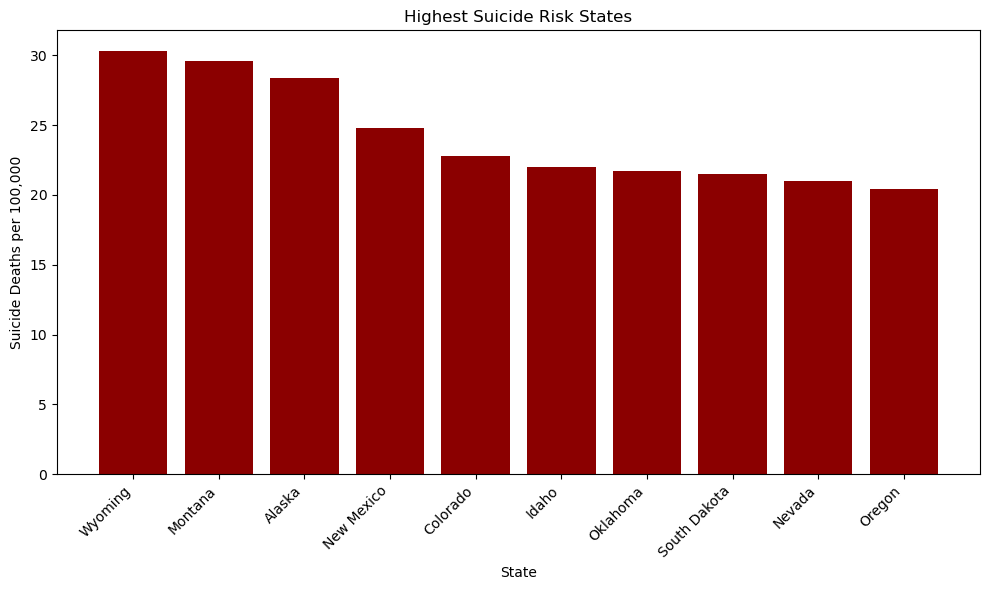

In [110]:
#Graphing Suicide
HighestSuicideRisk = HighestSuicide_df.head(10)
plt.figure(figsize=(10, 6)) 
plt.bar(HighestSuicide_df['State'], HighestSuicide_df['Suicide Crude Rate'], color='darkred')
plt.title('Highest Suicide Risk States')
plt.xlabel('State')
plt.ylabel('Suicide Deaths per 100,000')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.savefig("../Figures/HighestSuicideRisk.png")
plt.show()

In [115]:
#Highest SUD States
HighestSUD_df=All_df[["State","Suicide Crude Rate", "SUD Crude Rate", "% of Surveyors Who Got Help", "% of Surveyors Who Did Not Get Help", "Ratio of Surveyors Who Did Not Get Help"]]
HighestSUD_df = HighestSUD_df.groupby('State').mean().round(2)
HighestSUD_df=HighestSUD_df.sort_values(by=['SUD Crude Rate'], ascending=False).reset_index()
HighestSUD_df=HighestSUD_df[HighestSUD_df.index < 10]
HighestSUD_df.head(11)

,State,Suicide Crude Rate,SUD Crude Rate,% of Surveyors Who Got Help,% of Surveyors Who Did Not Get Help,Ratio of Surveyors Who Did Not Get Help
0,West Virginia,20.23,1461.77,31.93,10.47,0.33
1,Mississippi,14.73,1276.60,24.93,10.93,0.44
2,Tennessee,17.60,1254.17,26.57,11.30,0.42
3,Kentucky,18.07,1235.30,30.07,11.30,0.38
4,Alabama,16.33,1234.23,27.73,11.23,0.41
5,Arkansas,19.17,1222.23,28.93,11.83,0.41
6,Ohio,14.77,1194.27,26.87,10.47,0.39
7,Missouri,19.03,1190.13,27.43,11.73,0.43
8,Pennsylvania,14.30,1170.13,27.60,9.50,0.35
9,Louisiana,14.80,1169.23,27.97,10.93,0.39


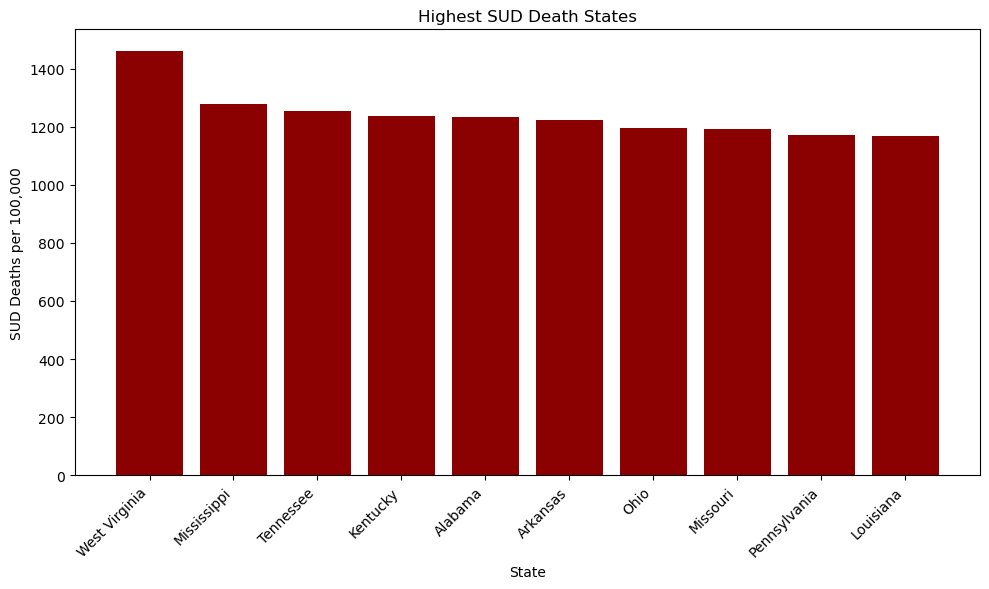

In [116]:
#Graphing SUD
HighestSUDRisk = HighestSUD_df.head(10)
plt.figure(figsize=(10, 6)) 
plt.bar(HighestSUD_df['State'], HighestSUD_df['SUD Crude Rate'], color='darkred')
plt.title('Highest SUD Death States')
plt.xlabel('State')
plt.ylabel('SUD Deaths per 100,000')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.savefig("../Figures/HighestSUDRisk.png")
plt.show()

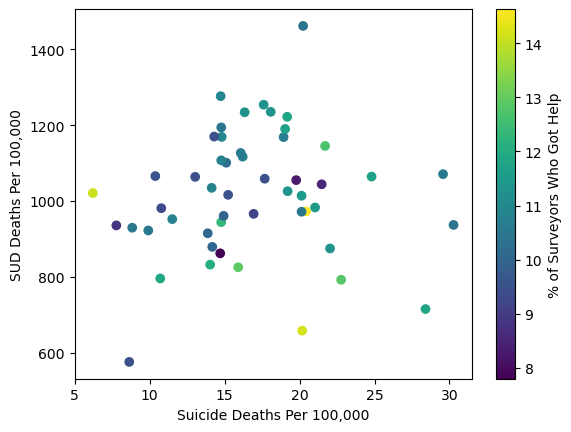

In [120]:
#Comparison - Did not use this data
AllState_df=All_df[["State","Suicide Crude Rate", "SUD Crude Rate", "% of Surveyors Who Got Help", "% of Surveyors Who Did Not Get Help", "Ratio of Surveyors Who Did Not Get Help"]]
AllState_df = AllState_df.groupby('State').mean().round(2)
SCR=AllState_df['Suicide Crude Rate']
SUDCR=AllState_df['SUD Crude Rate']
Survey=AllState_df["% of Surveyors Who Got Help"]
plt.scatter(SCR,SUDCR,c=RS)
clb=plt.colorbar()
plt.xlabel("Suicide Deaths Per 100,000")
plt.ylabel("SUD Deaths Per 100,000")
clb.set_label("% of Surveyors Who Got Help")
plt.show()

In [124]:
#The 20 At-Risk States
AtRisk_df=All_df[All_df['State'].isin(["Wyoming","Montana","Alaska","New Mexico","Colorado","Idaho","Oklahoma","South Dakota","Nevada","Oregon","West Virginia","Mississippi","Tennessee","Kentucky","Alabama","Arkansas","Ohio","Missouri","Pennsylvania","Louisiana"])]
AtRisk_df=AtRisk_df[["Year","Suicide Crude Rate", "SUD Crude Rate", "% of Surveyors Who Got Help", "% of Surveyors Who Did Not Get Help", "Ratio of Surveyors Who Did Not Get Help"]]
AtRisk_df = AtRisk_df.groupby('Year').mean().round(2).reset_index()
AtRisk_df.head(20)

,Year,Suicide Crude Rate,SUD Crude Rate,% of Surveyors Who Got Help,% of Surveyors Who Did Not Get Help,Ratio of Surveyors Who Did Not Get Help
0,2020,20.10,966.30,25.22,10.82,0.43
1,2021,21.22,1151.54,26.68,11.25,0.42
2,2022,20.40,1183.76,27.87,11.80,0.43


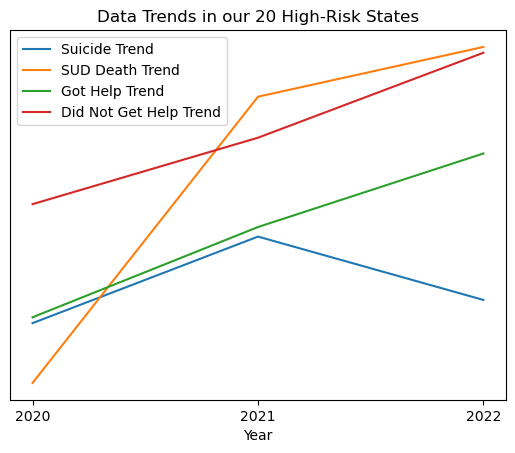

In [143]:
#Plotting Trends - Just trying to show correlation so actual numbers on y axis dont matter; want them close enough to see lines nearby eachother
Year=AtRisk_df['Year']
SCR=AtRisk_df['Suicide Crude Rate']
SUDCR=(AtRisk_df['SUD Crude Rate']/50)
GH=(AtRisk_df['% of Surveyors Who Got Help']/1.25)
NH=(AtRisk_df['% of Surveyors Who Did Not Get Help']*2)
SCRG = plt.plot(Year,SCR, label="Suicide Trend")
SUDCRG = plt.plot(Year,SUDCR, label="SUD Death Trend")
GHG = plt.plot(Year,GH, label="Got Help Trend")
NHG = plt.plot(Year,NH, label="Did Not Get Help Trend")
plt.legend(loc="best")
plt.title('Data Trends in our 20 High-Risk States')
plt.xlabel('Year')
plt.yticks([])
plt.xticks([2020, 2021, 2022])
plt.savefig("../Figures/Trends.png")
plt.show()